# Stochastic Hydrology - Semester project 
## Group 26 Alisa Tarnovskaya, Javier Feller

## 1. Data loading

In [61]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from scipy.stats import genextreme as gev
import numpy as np
import pymannkendall as mk

### 1.1 Inspect hydrological and attribut data

In [63]:
hydro_df=pd.read_csv(r"..\data\static_attributes\CAMELS_CH_hydrology_attributes_obs.csv", skiprows=1)
attributes_df=pd.read_csv(r"..\data\static_attributes\CAMELS_CH_topographic_attributes.csv", encoding="cp1252", skiprows=1)
hydro_df.columns
hydro_df.head(10)

,gauge_id,sign_start_date,sign_end_date,sign_number_of_years,q_mean,runoff_ratio,stream_elas,slope_fdc,baseflow_index_landson,hfd_mean,Q5,Q95,high_q_freq,high_q_dur,low_q_freq,low_q_dur,zero_q_freq
0,2004,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2007,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2009,1981-10-01,2020-09-30,39,3.090,0.868,0.767,1.296,0.787,243.282,1.279,6.207,0.000,0.000,0.051,2.000,0.0
3,2011,1981-10-01,2020-09-30,39,2.675,0.787,0.800,2.390,0.751,263.667,0.821,6.681,0.051,1.000,0.436,1.000,0.0
4,2014,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2016,1981-10-01,2020-09-30,39,2.327,0.637,1.122,1.131,0.786,201.974,1.044,4.562,0.000,0.000,0.000,0.000,0.0
6,2017,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2018,1981-10-01,2020-09-30,39,3.556,0.817,1.045,1.781,0.767,237.410,1.189,7.400,0.000,0.000,0.000,0.000,0.0
8,2019,1981-10-01,2020-09-30,39,5.671,1.119,0.589,2.332,0.754,255.538,1.532,12.104,0.077,1.500,5.769,2.394,0.0
9,2020,1981-10-01,2020-09-30,39,3.692,0.811,1.013,1.694,0.683,223.718,1.110,8.963,1.462,1.326,1.385,1.174,0.0


#### 1.2 Overview of all gauging stations in Switzerland

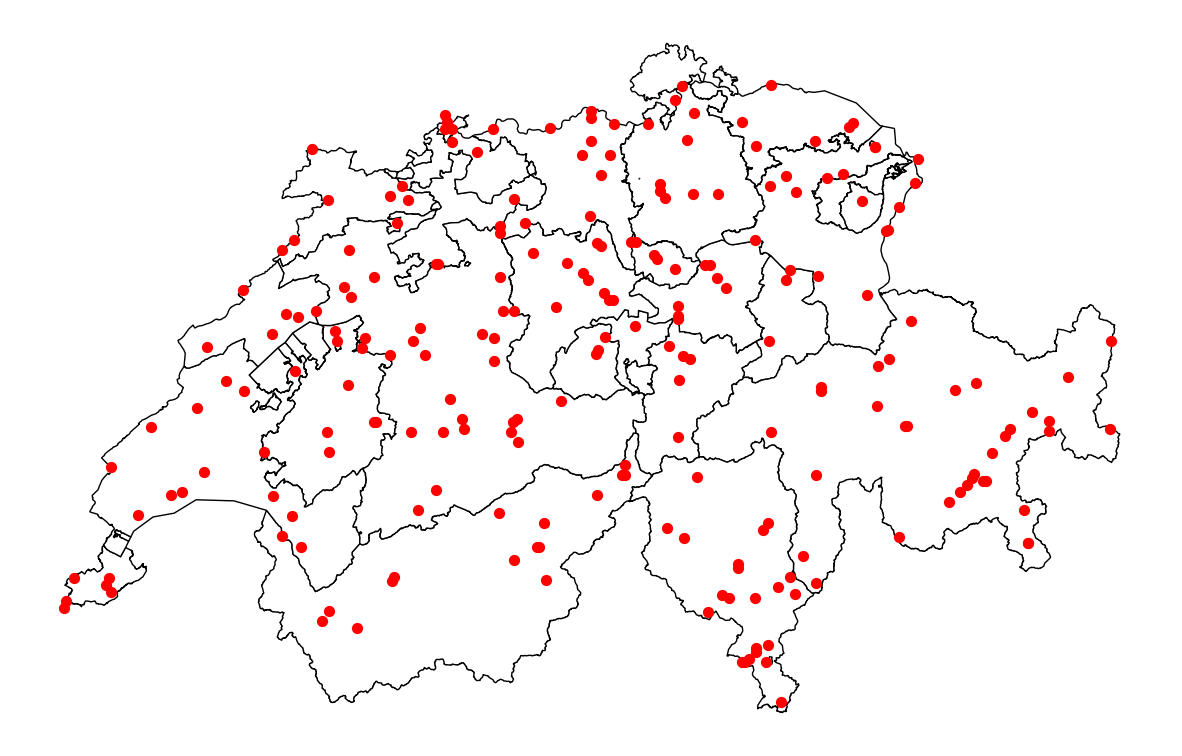

In [64]:
boundaries=gpd.read_file(r"..\data\swissboundaries3d_2026-01_2056_5728.gpkg\swissBOUNDARIES3D_1_5_LV95_LN02.gpkg", layer="tlm_kantonsgebiet")
attributes_df=attributes_df[attributes_df["country"]=="CH"]
attributes_gdf=gpd.GeoDataFrame(attributes_df, geometry=gpd.points_from_xy(attributes_df["gauge_lon"], attributes_df["gauge_lat"]), crs=4326)

attributes_gdf=attributes_gdf.to_crs(2056)
boundaries=boundaries.to_crs(2056)
fig, ax = plt.subplots(figsize=(15, 16))


boundaries.plot(ax=ax, color="white", edgecolor="black")

attributes_gdf.plot(ax=ax, color="red", markersize=50)

ax.set_axis_off()
plt.show()

### 1.3 Select gauging stations of watershed Rhone

In [65]:
attributes_df[attributes_df["water_body_name"]=="Rhône"]

,gauge_id,country,gauge_name,water_body_name,id6,water_body_type,gauge_lon,gauge_lat,gauge_easting,gauge_northing,...,elev_min,elev_percentile10,elev_percentile25,elev_percentile50,elev_percentile75,elev_percentile90,elev_max,slope_mean,flat_area_perc,steep_area_perc
2,2009,CH,Porte_du_Scex,Rhône,RhoPor,stream,6.89,46.35,2557660,1133280,...,377.07,1015.99,1560.86,2191.36,2698.04,3103.99,4521.34,25.72,3.62,79.60
3,2011,CH,Sion,Rhône,RhoSio,stream,7.36,46.22,2593770,1118630,...,485.83,1209.13,1778.17,2379.66,2821.90,3208.04,4521.34,25.82,2.83,80.15
13,2024,CH,Branson,Rhône,RhoBra,stream,7.09,46.13,2573150,1108300,...,456.71,1119.07,1704.02,2323.10,2781.24,3171.12,4521.34,25.58,3.27,79.57
85,2174,CH,Chancy-Aux_Ripes,Rhône,RhoCha,stream,5.97,46.15,2486600,1112340,...,335.89,432.54,709.14,1464.81,2302.79,2864.01,4787.66,19.74,16.83,59.30
102,2217,CH,Chancy-Vers_Vaux,Rhône,RhoCVV,stream,5.96,46.13,2485440,1110040,...,329.87,432.08,696.37,1451.19,2293.60,2859.19,4787.66,19.61,17.02,58.85
210,2606,CH,Genève-Halle_de_l'ìle,Rhône,RhoGen,stream,6.14,46.20,2499890,1117850,...,367.12,416.65,749.42,1610.01,2437.17,2932.50,4521.34,20.21,16.95,61.12


### Check gauging station

In [40]:
hydro_df.columns
sion_gauge=hydro_df[hydro_df["gauge_id"]==2014]
sion_gauge.head(3)

,gauge_id,sign_start_date,sign_end_date,sign_number_of_years,q_mean,runoff_ratio,stream_elas,slope_fdc,baseflow_index_landson,hfd_mean,Q5,Q95,high_q_freq,high_q_dur,low_q_freq,low_q_dur,zero_q_freq
4,2014,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Branson gauging station- Rhone

In [66]:
branson_gauge_annual=pd.read_csv(r"..\data\timeseries\observation_based\CAMELS_CH_obs_based_2014.csv")
branson_gauge_annual["date"] = pd.to_datetime(branson_gauge_annual["date"])

branson_gauge_90 = branson_gauge_annual[branson_gauge_annual["date"] > "2010-01-01"]
branson_gauge_90.head(3)

,date,discharge_vol(m3/s),discharge_spec(mm/d),waterlevel(m),precipitation(mm/d),temperature_min(degC),temperature_mean(degC),temperature_max(degC),rel_sun_dur(%),swe(mm)
10593,2010-01-02,NaN,NaN,405.861,1.33,-12.41,-8.76,-5.59,1.12,45.0
10594,2010-01-03,NaN,NaN,405.824,0.00,-13.13,-10.05,-6.27,97.03,46.0
10595,2010-01-04,NaN,NaN,405.809,1.17,-11.14,-7.20,-5.24,0.74,46.0


#### Sion gauging station - Rhone

In [42]:
sion_gauge=hydro_df[hydro_df["gauge_id"]==2011]
sion_gauge_annual=pd.read_csv(r"..\data\timeseries\observation_based\CAMELS_CH_obs_based_2011.csv")
sion_gauge_annual["date"] = pd.to_datetime(sion_gauge_annual["date"])

sion_gauge_90 = sion_gauge_annual[sion_gauge_annual["date"] > "1990-01-01"]
sion_gauge_90.head(3)

,date,discharge_vol(m3/s),discharge_spec(mm/d),waterlevel(m),precipitation(mm/d),temperature_min(degC),temperature_mean(degC),temperature_max(degC),rel_sun_dur(%),swe(mm)
3288,1990-01-02,26.587,0.681,483.193,0.0,-10.33,-7.37,-3.37,99.19,NaN
3289,1990-01-03,36.718,0.941,483.359,0.0,-8.93,-6.45,-2.19,99.50,NaN
3290,1990-01-04,44.049,1.129,483.461,0.0,-10.36,-7.43,-2.88,99.74,NaN


#### Sion gauging station - Rhone - Daily discharge frequency diagram 1990-2020

<Axes: title={'center': 'Daily discharge [m3/s] at gauging station of Sion'}, xlabel='Date', ylabel='Discharge [m3/s] '>

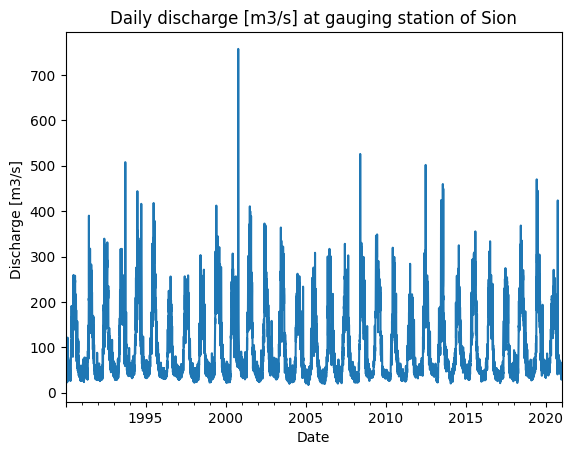

In [43]:
sion_gauge_90["date"] = pd.to_datetime(sion_gauge_90["date"])
sion_gauge_90 = sion_gauge_90.set_index("date", drop=False)

sion_gauge_90["discharge_vol(m3/s)"].plot(title="Daily discharge [m3/s] at gauging station of Sion", xlabel="Date", ylabel="Discharge [m3/s] ")


## 2. Frequency analysis

### 2.1 Check for stationarity

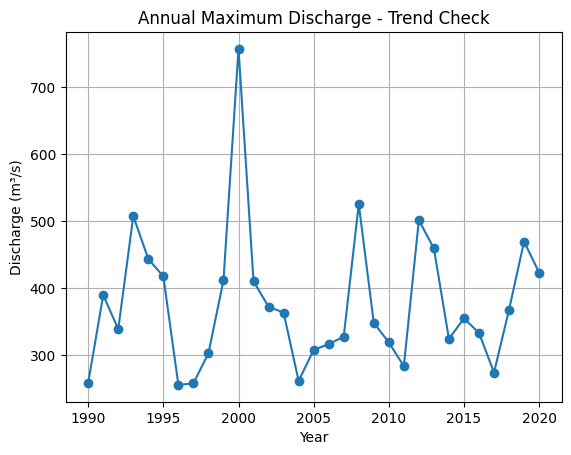

In [67]:
import matplotlib.pyplot as plt

annual_max=sion_gauge_90["discharge_vol(m3/s)"].resample("YE").max()
annual_max = annual_max.dropna()

plt.plot(annual_max.index.year, annual_max.values, marker="o")
plt.title("Annual Maximum Discharge - Trend Check")
plt.xlabel("Year")
plt.ylabel("Discharge (m³/s)")
plt.grid(True)
plt.show()

### Check for significant trends using Mann-kendal test (non-linear)

In [68]:
result = mk.original_test(annual_max.values)
print(result)

Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.6833368087995224), z=np.float64(0.4079140071942694), Tau=np.float64(0.053763440860215055), s=np.float64(25.0), var_s=3461.6666666666665, slope=np.float64(0.7543750000000031), intercept=np.float64(344.0363749999999))


In [69]:
# check for data period (30-50 years are good)
len(annual_max.dropna())

31

### 2.1 Extreme value analysis using return period of 2 or 10 years

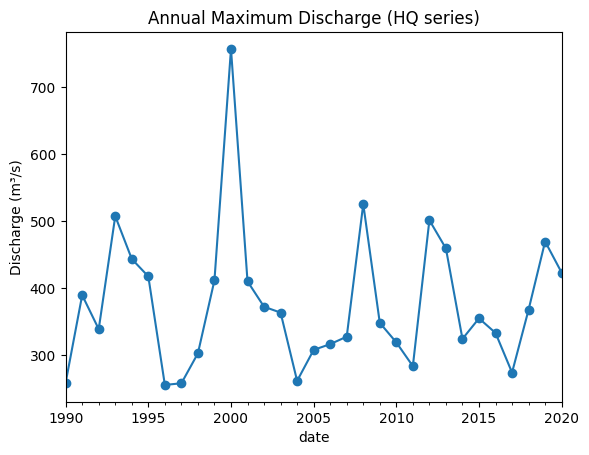

In [47]:
annual_max=sion_gauge_90["discharge_vol(m3/s)"].resample("YE").max()

annual_max.plot(marker="o")
plt.title("Annual Maximum Discharge (HQ series)")
plt.ylabel("Discharge (m³/s)")
plt.show()

### 2.2 Fit parameters of distribution and plot

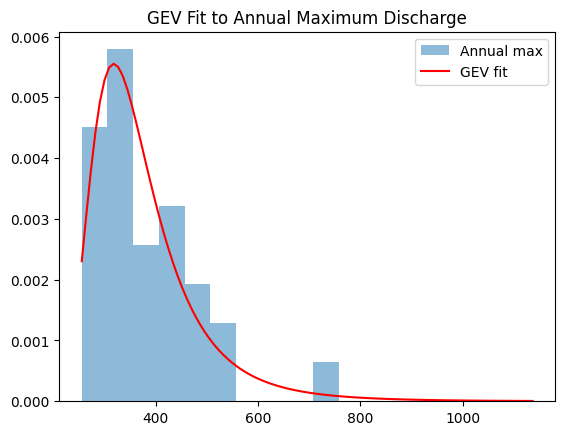

In [70]:
data = annual_max.dropna().values
shape, loc, scale = gev.fit(data)

#compute
x = np.linspace(min(data), max(data)*1.5, 100)

pdf = gev.pdf(x, shape, loc=loc, scale=scale)

# Plot
plt.hist(data, bins=10, density=True, alpha=0.5, label="Annual max")
plt.plot(x, pdf, "r-", label="GEV fit")

plt.legend()
plt.title("GEV Fit to Annual Maximum Discharge")
plt.show()

### 2.3 Check with goodness of fit test QQ-plot

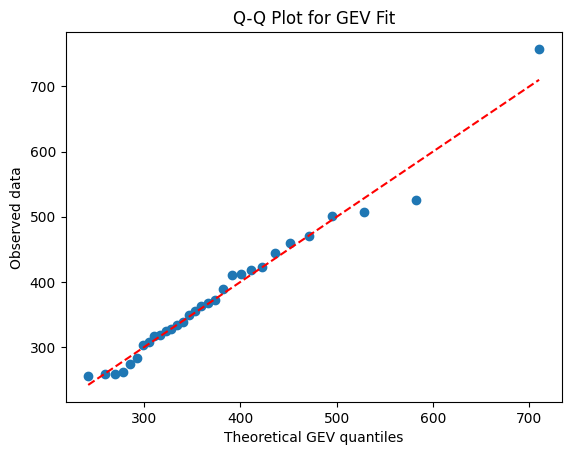

In [71]:

# empirical quantiles
sorted_data = np.sort(data)
n = len(data)
probs = (np.arange(1, n+1) - 0.5) / n

theoretical = gev.ppf(probs, shape, loc=loc, scale=scale)

plt.scatter(theoretical, sorted_data)
plt.plot([min(theoretical), max(theoretical)],
         [min(theoretical), max(theoretical)],
         'r--')

plt.xlabel("Theoretical GEV quantiles")
plt.ylabel("Observed data")
plt.title("Q-Q Plot for GEV Fit")
plt.show()

### 2.4 Estimate flood magnitude

In [72]:
def return_level(T):
    p = 1 - 1/T
    return gev.ppf(p, shape, loc=loc, scale=scale)

# Define different return periods
HQ2 = round(return_level(2))
HQ10 = round(return_level(10))
HQ100 = round(return_level(100))

print("HQ2:", HQ2)
print("HQ10:", HQ10)
print("HQ100:", HQ100)

HQ2: 353
HQ10: 507
HQ100: 772


### 2.5 Include uncertainty with bootstrapping

In [74]:
# normal confidence interval only makes sense when estimator is approximately normal and variance is known analytically
# 👉 For GEV return levels: usually NOT the case → bootstrap is safer

def bootstrap_all_return_levels(data, Ts, n_boot=500):
    np.random.seed(42)

    n = len(data)
    boot = {T: np.empty(n_boot) for T in Ts}

    for i in range(n_boot):
        sample = np.random.choice(data, size=n, replace=True)

        c, loc_b, scale_b = gev.fit(sample)

        for T in Ts:
            p = 1 - 1/T
            boot[T][i] = gev.ppf(p, c, loc_b, scale_b)

    return {
        T: np.percentile(boot[T], [2.5, 50, 97.5])
        for T in Ts
    }

In [53]:
results = bootstrap_all_return_levels(data, Ts=[2, 10, 100], n_boot=500)

ci_2 = results[2]
ci_10 = results[10]
ci_100 = results[100]

In [55]:
# structure: lower, median (best estimate), upper
print("HQ2  CI:", ci_2)
print("HQ10 CI:", ci_10)
print("HQ100 CI:", ci_100)

HQ2  CI: [256.7398303  328.27459549 400.71480822]
HQ10 CI: [4.33998314e+02 5.67054869e+02 1.61555449e+07]
HQ100 CI: [5.16968805e+02 1.23420505e+03 9.11695707e+14]


## 3. Time series analysis

### 3.1 Time series- assumptions

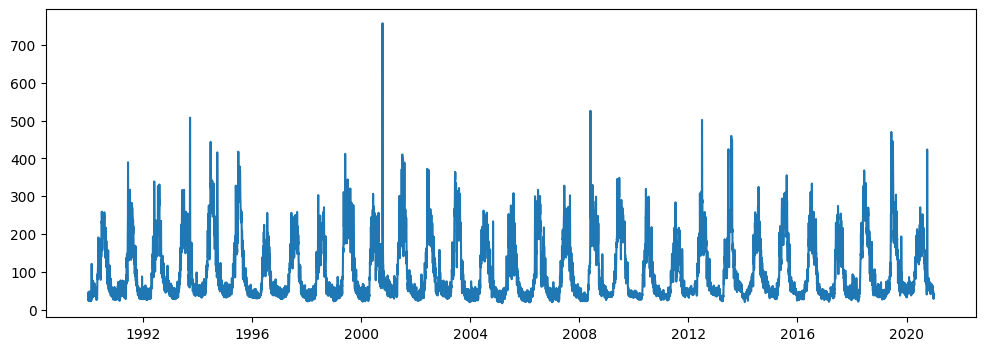

In [111]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(
    sion_gauge_90["date"],
    sion_gauge_90["discharge_vol(m3/s)"]
)
plt.show()

#### 3.2 Remove seasonality

In [112]:
sion_gauge_90["doy"] = sion_gauge_90["date"].dt.dayofyear
seasonal = (
    sion_gauge_90
    .groupby("doy")["discharge_vol(m3/s)"]
    .mean()
)

sion_gauge_90["seasonal"] = (
    sion_gauge_90["doy"].map(seasonal)
)

sion_gauge_90["deseasoned"] = (
    sion_gauge_90["discharge_vol(m3/s)"]
    - sion_gauge_90["seasonal"]
)

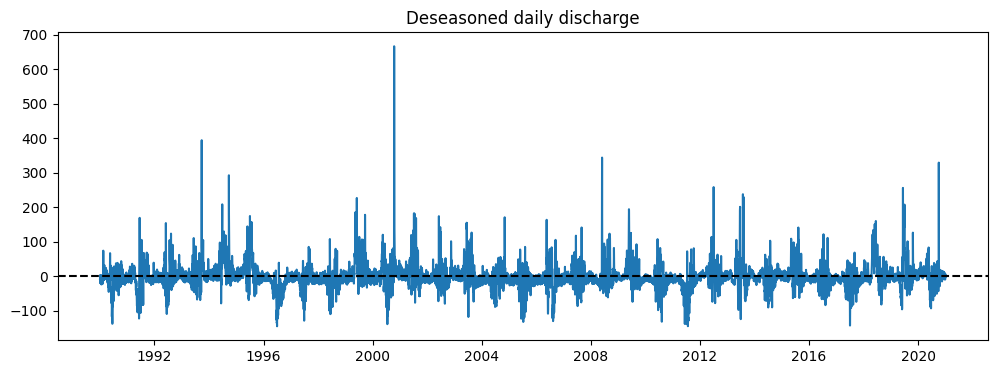

In [113]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(
    sion_gauge_90["date"],
    sion_gauge_90["deseasoned"]
)
plt.axhline(0, color="black", linestyle="--")
plt.title("Deseasoned daily discharge")
plt.show()

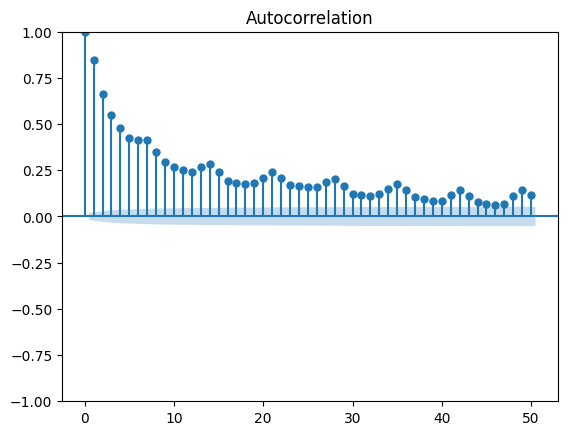

In [115]:
sion_gauge_90["trend"] = trend_model.predict(X)

sion_gauge_90["residuals"] = (
    sion_gauge_90["deseasoned"]
    - sion_gauge_90["trend"]
)

from statsmodels.graphics.tsaplots import plot_acf

plot_acf(
    sion_gauge_90["residuals"].dropna(),
    lags=50
)
plt.show()

In [116]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

sion_gauge_90["t"] = (sion_gauge_90["date"] - sion_gauge_90["date"].min()).dt.days

X = sm.add_constant(sion_gauge_90["t"])
model = sm.OLS(sion_gauge_90["discharge_vol(m3/s)"], X).fit()

print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     discharge_vol(m3/s)   R-squared:                       0.000
Model:                             OLS   Adj. R-squared:                  0.000
Method:                  Least Squares   F-statistic:                     2.397
Date:                 Tue, 02 Jun 2026   Prob (F-statistic):              0.122
Time:                         16:39:22   Log-Likelihood:                -65279.
No. Observations:                11322   AIC:                         1.306e+05
Df Residuals:                    11320   BIC:                         1.306e+05
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        104.9988      1.452     72.33

#### Trend to build residuals column

In [117]:
sion_gauge_90["trend"] = model.predict(X)

In [118]:
sion_gauge_90["residuals"] = model.resid

### 3.2 Testing for autocorrelation in residuals

In [108]:
from statsmodels.stats.diagnostic import acorr_ljungbox

print(acorr_ljungbox(
    sion_gauge_90["residuals"].dropna(),
    lags=[10, 20],
    return_df=True
))

          lb_stat  lb_pvalue
10   85646.516259        0.0
20  153156.395774        0.0


#### 3.3 Stochastic model

In [110]:
from statsmodels.tsa.arima.model import ARIMA

y = sion_gauge_90["discharge_vol(m3/s)"]

model_ar = ARIMA(y, order=(1,0,0)).fit()

print(model_ar.summary())

c:\Users\Javier Feller\miniconda3\envs\stochastic_hydrology\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Javier Feller\miniconda3\envs\stochastic_hydrology\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Javier Feller\miniconda3\envs\stochastic_hydrology\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                SARIMAX Results                                
Dep. Variable:     discharge_vol(m3/s)   No. Observations:                11322
Model:                  ARIMA(1, 0, 0)   Log Likelihood              -50258.654
Date:                 Tue, 02 Jun 2026   AIC                         100523.309
Time:                         16:36:41   BIC                         100545.312
Sample:                     01-02-1990   HQIC                        100530.711
                          - 12-31-2020                                         
Covariance Type:                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        103.0526      7.412     13.903      0.000      88.524     117.581
ar.L1          0.9642      0.002    619.072      0.000       0.961       0.967
sigma2       419.8690      1.359    308.959 

## 4. Multivariate analysis (new method)